# Climate Change Slope Analysis: Decision Tree Modeling

This notebook uses a Decision Tree model to predict local climate change slope based on geographical and climatological factors.

## Overview
- **Part 1**: Load data with climatological features (automatically added by main.py)
- **Part 2**: Build decision tree model using geographical and climatological features
- **Part 3**: Generate predictions and compare with actual slopes
- **Part 4**: Visualize decision tree structure and model performance

**Note:** Make sure to run `main.py` first to generate station_data.csv with all climatological features.

## Configuration

Set the file paths for input data and output results:

In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import os
from pathlib import Path

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [21]:
# Configuration: File Paths
ORIGINAL_DATA_CSV = '../output/station_data.csv'          # Input data with all features
OUTPUT_DIR = '../output/decision_tree'

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input file: {ORIGINAL_DATA_CSV}")
print(f"Output directory: {OUTPUT_DIR}")

Input file: ../output/station_data.csv
Output directory: ../output/decision_tree


## Part 1: Data Loading & Exploration

Load the station data and explore its structure:

In [23]:
# Load the data
print(f"Loading data from '{ORIGINAL_DATA_CSV}'...")
try:
    df = pd.read_csv(ORIGINAL_DATA_CSV)
    print(f"Successfully loaded {len(df)} stations")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    raise

# Display basic information
print("\n--- Data Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- First few rows ---")
df.head()

Loading data from '../output/station_data.csv'...
Successfully loaded 21 stations

--- Data Shape ---
Rows: 21, Columns: 13

--- First few rows ---


,StationID,Latitude,Longitude,Elevation,StationName,slope,intercept,r_squared,regression_plot,residual_plot,timeseries_plot,climo_temp,climo_humidity
0,USC00083207,27.4419,-80.3508,7.6,FT_PIERCE,1.272192,-0.317535,0.588628,plots/USC00083207/regression.png,plots/USC00083207/residual.png,plots/USC00083207/timeseries.png,23.127167,74.000000
1,CHM00057713,27.7000,106.8830,845.0,ZUNYI,1.083615,-0.147224,0.421044,plots/CHM00057713/regression.png,plots/CHM00057713/residual.png,plots/CHM00057713/timeseries.png,16.136410,76.783333
2,ASN00066037,-33.9465,151.1731,6.0,SYDNEY_AIRPORT_AMO,1.590236,-0.374604,0.738315,plots/ASN00066037/regression.png,plots/ASN00066037/residual.png,plots/ASN00066037/timeseries.png,18.523897,62.341667
3,USW00013991,39.1342,-93.2225,240.8,MARSHALL,0.410177,-0.101153,0.044680,plots/USW00013991/regression.png,plots/USW00013991/residual.png,plots/USW00013991/timeseries.png,12.560768,69.458333
4,USC00103143,46.0931,-115.5356,475.5,FENN_RS,0.697019,-0.107765,0.197517,plots/USC00103143/regression.png,plots/USC00103143/residual.png,plots/USC00103143/timeseries.png,10.272943,63.508333


In [24]:
# Display data info and statistics
print("\n--- Data Types ---")
print(df.dtypes)

missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print("\n--- Missing Values ---")
    print(missing_data[missing_data > 0])

print("\n--- Column Names ---")
print(df.columns.tolist())


--- Data Types ---
StationID              str
Latitude           float64
Longitude          float64
Elevation          float64
StationName            str
slope              float64
intercept          float64
r_squared          float64
regression_plot        str
residual_plot          str
timeseries_plot        str
climo_temp         float64
climo_humidity     float64
dtype: object

--- Missing Values ---
climo_humidity    2
dtype: int64

--- Column Names ---
['StationID', 'Latitude', 'Longitude', 'Elevation', 'StationName', 'slope', 'intercept', 'r_squared', 'regression_plot', 'residual_plot', 'timeseries_plot', 'climo_temp', 'climo_humidity']


## Part 2: Decision Tree Model Training

This section builds a decision tree model to predict climate change slope based on:
- **Features**: `climo_temp`, `climo_humidity`, `Latitude`, `Longitude`, `Elevation`
- **Target**: `slope` (local climate change trend)

In [25]:
# Define target and features
target_col = 'slope'
feature_cols = ['climo_temp', 'climo_humidity', 'Latitude', 'Longitude', 'Elevation']

# Data cleaning
print("--- Data Cleaning ---")
missing_cols = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing_cols:
    print(f"Error: Missing columns: {missing_cols}")
else:
    print(f"All required columns present: {feature_cols + [target_col]}")

# Drop rows with missing values
initial_count = len(df)
df_clean = df.dropna(subset=[target_col] + feature_cols)
cleaned_count = len(df_clean)

if cleaned_count < initial_count:
    print(f"Dropped {initial_count - cleaned_count} rows due to missing data")
    print(f"  Remaining records: {cleaned_count}")
else:
    print(f"No missing values in regression variables")

if cleaned_count == 0:
    print("Error: No data remaining after cleaning")
    raise ValueError("Empty dataset after cleaning")

--- Data Cleaning ---
All required columns present: ['climo_temp', 'climo_humidity', 'Latitude', 'Longitude', 'Elevation', 'slope']
Dropped 2 rows due to missing data
  Remaining records: 19


In [26]:
# Prepare data for decision tree
X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

print(f"\n--- Decision Tree Setup ---")
print(f"Total observations: {len(y)}")
print(f"Features: {feature_cols}")
print(f"\nDependent Variable ({target_col}) Statistics:")
print(f"  Mean: {y.mean():.6f}")
print(f"  Std: {y.std():.6f}")
print(f"  Min: {y.min():.6f}")
print(f"  Max: {y.max():.6f}")

print(f"\nFeature Statistics:")
print(X.describe())


--- Decision Tree Setup ---
Total observations: 19
Features: ['climo_temp', 'climo_humidity', 'Latitude', 'Longitude', 'Elevation']

Dependent Variable (slope) Statistics:
  Mean: 1.536063
  Std: 0.893260
  Min: 0.410177
  Max: 3.350626

Feature Statistics:
       climo_temp  climo_humidity   Latitude   Longitude    Elevation
count   19.000000       19.000000  19.000000   19.000000    19.000000
mean     9.514297       71.769298  39.747258  -27.194295   494.200000
std      7.433919        5.883735  20.149945   89.408308   465.823913
min     -9.581026       60.616667 -33.946500 -116.840000     6.000000
25%      4.447140       68.016667  36.272500  -93.835300   174.950000
50%     10.740473       73.616667  45.650300  -80.350800   353.600000
75%     13.720553       75.987500  49.562650   14.443350   585.950000
max     23.127167       81.600000  59.855800  151.173100  1691.600000


In [27]:
# Split data into training and testing sets
print("--- Splitting Data ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

--- Splitting Data ---
Training set size: 15 (78.9%)
Testing set size: 4 (21.1%)


In [28]:
# Build and train decision tree model
print("\n--- Training Decision Tree Model ---")

# Create decision tree with controlled depth to avoid overfitting
dt_model = DecisionTreeRegressor(
    max_depth=10,                  # Limit tree depth
    min_samples_split=5,           # Minimum samples to split
    min_samples_leaf=2,            # Minimum samples in leaf
    random_state=42
)

# Train on training set
dt_model.fit(X_train, y_train)

print("✓ Decision tree model trained successfully")
print(f"\nTree Structure:")
print(f"  Depth: {dt_model.get_depth()}")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")
print(f"  Number of features used: {dt_model.n_features_in_}")


--- Training Decision Tree Model ---
✓ Decision tree model trained successfully

Tree Structure:
  Depth: 3
  Number of leaves: 5
  Number of features used: 5


## Part 3: Model Evaluation & Predictions

Evaluate the model performance and generate predictions:

In [29]:
# Make predictions on both training and test sets
print("--- Making Predictions ---")
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate metrics on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics on test set
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n--- Training Set Performance ---")
print(f"  R² Score: {train_r2:.4f}")
print(f"  Mean Squared Error: {train_mse:.6f}")
print(f"  Root Mean Squared Error: {train_rmse:.6f}")
print(f"  Mean Absolute Error: {train_mae:.6f}")

print(f"\n--- Test Set Performance ---")
print(f"  R² Score: {test_r2:.4f}")
print(f"  Mean Squared Error: {test_mse:.6f}")
print(f"  Root Mean Squared Error: {test_rmse:.6f}")
print(f"  Mean Absolute Error: {test_mae:.6f}")

# Check for overfitting
overfit_ratio = train_r2 / test_r2 if test_r2 > 0 else float('inf')
print(f"\nOverfitting Check (Train R²/Test R²): {overfit_ratio:.2f}")
if overfit_ratio > 1.2:
    print("  ⚠ Model shows signs of overfitting")
else:
    print("  ✓ Model generalization looks good")

--- Making Predictions ---

--- Training Set Performance ---
  R² Score: 0.9648
  Mean Squared Error: 0.029715
  Root Mean Squared Error: 0.172380
  Mean Absolute Error: 0.148463

--- Test Set Performance ---
  R² Score: -1.3755
  Mean Squared Error: 0.735017
  Root Mean Squared Error: 0.857331
  Mean Absolute Error: 0.645051

Overfitting Check (Train R²/Test R²): inf
  ⚠ Model shows signs of overfitting



5-FOLD CROSS-VALIDATION ANALYSIS

Performing 5-fold cross-validation...

--- Cross-Validation R² Scores (5 Folds) ---
  Fold 1: Train R² = 0.9648, Test R² = -1.3755
  Fold 2: Train R² = 0.9467, Test R² = 0.9578
  Fold 3: Train R² = 0.9738, Test R² = -3.0539
  Fold 4: Train R² = 0.9641, Test R² = -5.5857
  Fold 5: Train R² = 0.9420, Test R² = -8.4648

--- Cross-Validation Summary ---
R² Scores:
  Train: Mean = 0.9583 (±0.0120)
  Test:  Mean = -3.5044 (±3.2736)

RMSE Scores:
  Mean = 0.970243 (±0.512634)

MAE Scores:
  Mean = 0.786960 (±0.514958)

--- Comparison: Single Train/Test Split vs Cross-Validation ---
Single Split Test R²:       -8.4648
CV Average Test R²:         -3.5044 (±3.2736)
Cross-Validation is more robust and uses all data for both training and testing.


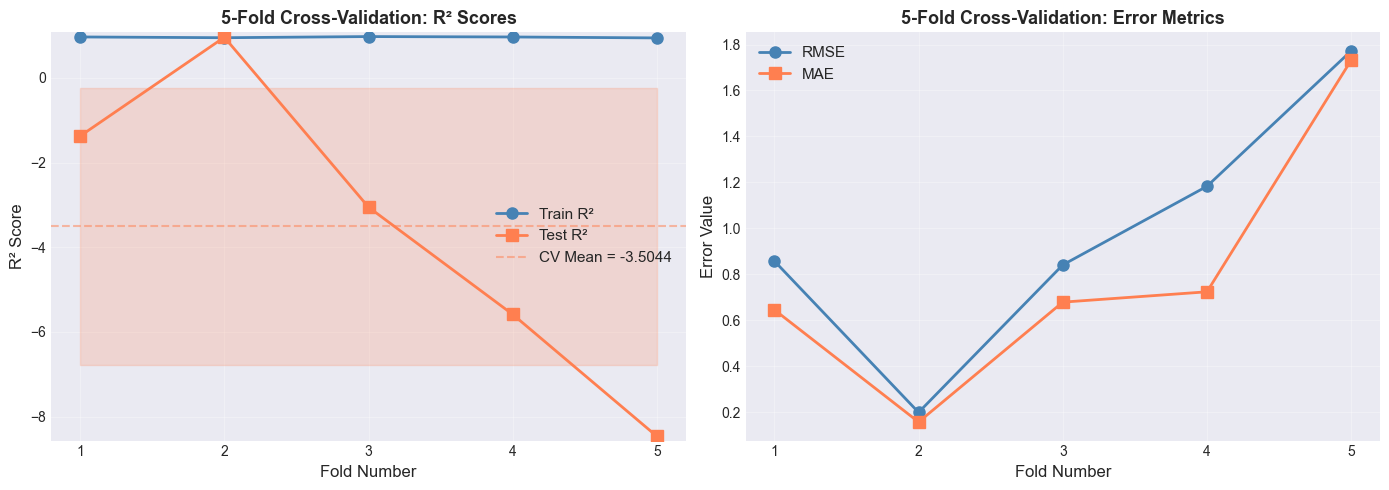


✓ Cross-validation analysis complete


In [30]:
# Perform 5-fold cross-validation
from sklearn.model_selection import cross_val_score, cross_validate, KFold

print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION ANALYSIS")
print("="*60)

# Define KFold splitter
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Create multiple scoring metrics
scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

# Perform cross-validation on full dataset
print("\nPerforming 5-fold cross-validation...")
cv_results = cross_validate(dt_model, X, y, cv=kfold, scoring=scoring, return_train_score=True)

# Extract and display results
cv_r2_train = cv_results['train_r2']
cv_r2_test = cv_results['test_r2']
cv_mse_test = -cv_results['test_neg_mse']  # Negate to get positive MSE
cv_mae_test = -cv_results['test_neg_mae']  # Negate to get positive MAE
cv_rmse_test = np.sqrt(cv_mse_test)

print(f"\n--- Cross-Validation R² Scores (5 Folds) ---")
for i, (train_r2, test_r2) in enumerate(zip(cv_r2_train, cv_r2_test), 1):
    print(f"  Fold {i}: Train R² = {train_r2:.4f}, Test R² = {test_r2:.4f}")

print(f"\n--- Cross-Validation Summary ---")
print(f"R² Scores:")
print(f"  Train: Mean = {cv_r2_train.mean():.4f} (±{cv_r2_train.std():.4f})")
print(f"  Test:  Mean = {cv_r2_test.mean():.4f} (±{cv_r2_test.std():.4f})")

print(f"\nRMSE Scores:")
print(f"  Mean = {cv_rmse_test.mean():.6f} (±{cv_rmse_test.std():.6f})")

print(f"\nMAE Scores:")
print(f"  Mean = {cv_mae_test.mean():.6f} (±{cv_mae_test.std():.6f})")

# Compare with single train/test split
print(f"\n--- Comparison: Single Train/Test Split vs Cross-Validation ---")
print(f"Single Split Test R²:       {test_r2:.4f}")
print(f"CV Average Test R²:         {cv_r2_test.mean():.4f} (±{cv_r2_test.std():.4f})")
print(f"Cross-Validation is more robust and uses all data for both training and testing.")

# Visualize CV fold results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² scores for each fold
folds = np.arange(1, 6)
axes[0].plot(folds, cv_r2_train, 'o-', label='Train R²', linewidth=2, markersize=8, color='steelblue')
axes[0].plot(folds, cv_r2_test, 's-', label='Test R²', linewidth=2, markersize=8, color='coral')
axes[0].axhline(y=cv_r2_test.mean(), color='coral', linestyle='--', alpha=0.5, label=f'CV Mean = {cv_r2_test.mean():.4f}')
axes[0].fill_between(folds, 
                     cv_r2_test.mean() - cv_r2_test.std(),
                     cv_r2_test.mean() + cv_r2_test.std(),
                     alpha=0.2, color='coral')
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('5-Fold Cross-Validation: R² Scores', fontsize=13, fontweight='bold')
axes[0].set_xticks(folds)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_ylim([cv_r2_test.min() - 0.1, cv_r2_train.max() + 0.1])

# Plot 2: Error metrics for each fold
axes[1].plot(folds, cv_rmse_test, 'o-', label='RMSE', linewidth=2, markersize=8, color='steelblue')
axes[1].plot(folds, cv_mae_test, 's-', label='MAE', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Fold Number', fontsize=12)
axes[1].set_ylabel('Error Value', fontsize=12)
axes[1].set_title('5-Fold Cross-Validation: Error Metrics', fontsize=13, fontweight='bold')
axes[1].set_xticks(folds)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Cross-validation analysis complete")

In [31]:
# Create full dataset predictions for all stations
print("\n--- Creating Full Dataset Predictions ---")
df_predictions = df_clean.copy()
df_predictions['Predicted_Slope'] = dt_model.predict(X)
df_predictions['Actual_Slope'] = y
df_predictions['Residual'] = df_predictions['Actual_Slope'] - df_predictions['Predicted_Slope']

print(f"\n--- Full Dataset Statistics ---")
print(f"\nActual Slope:")
print(f"  Mean: {df_predictions['Actual_Slope'].mean():.6f}")
print(f"  Std Dev: {df_predictions['Actual_Slope'].std():.6f}")
print(f"  Range: [{df_predictions['Actual_Slope'].min():.6f}, {df_predictions['Actual_Slope'].max():.6f}]")

print(f"\nPredicted Slope:")
print(f"  Mean: {df_predictions['Predicted_Slope'].mean():.6f}")
print(f"  Std Dev: {df_predictions['Predicted_Slope'].std():.6f}")
print(f"  Range: [{df_predictions['Predicted_Slope'].min():.6f}, {df_predictions['Predicted_Slope'].max():.6f}]")

print(f"\nResiduals (Actual - Predicted):")
print(f"  Mean: {df_predictions['Residual'].mean():.6f}")
print(f"  Std Dev: {df_predictions['Residual'].std():.6f}")
print(f"  Range: [{df_predictions['Residual'].min():.6f}, {df_predictions['Residual'].max():.6f}]")


--- Creating Full Dataset Predictions ---

--- Full Dataset Statistics ---

Actual Slope:
  Mean: 1.536063
  Std Dev: 0.893260
  Range: [0.410177, 3.350626]

Predicted Slope:
  Mean: 1.449034
  Std Dev: 0.922562
  Range: [0.518369, 3.003740]

Residuals (Actual - Predicted):
  Mean: 0.087029
  Std Dev: 0.424387
  Range: [-0.461523, 1.551630]



--- Feature Importance ---
       Feature  Importance
    climo_temp    0.678910
     Elevation    0.193425
climo_humidity    0.127665
      Latitude    0.000000
     Longitude    0.000000


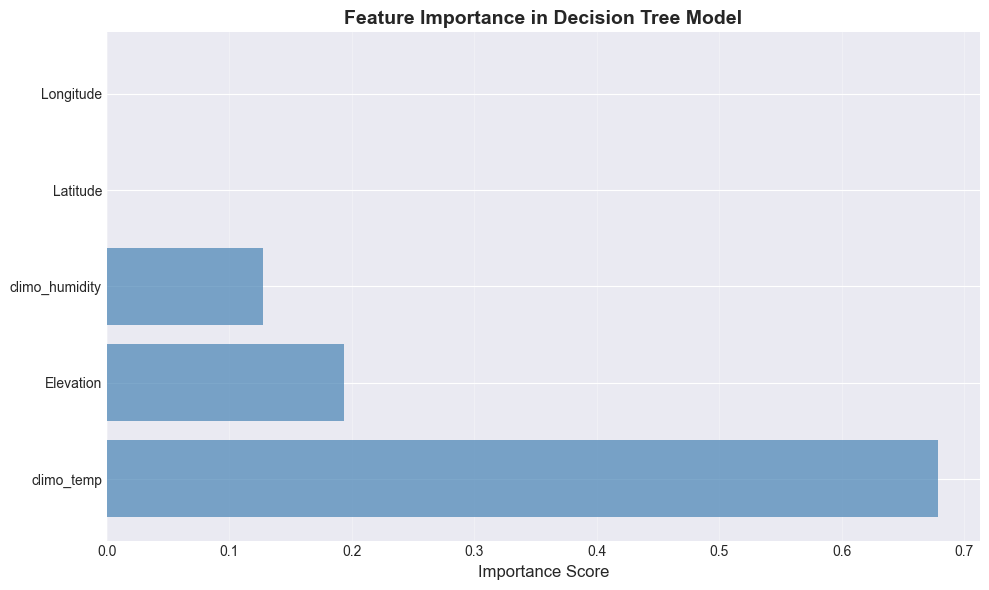

In [32]:
# Feature importance from decision tree
print("\n--- Feature Importance ---")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', alpha=0.7)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance in Decision Tree Model', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Part 4: Visualization

Visualize model performance and tree structure:

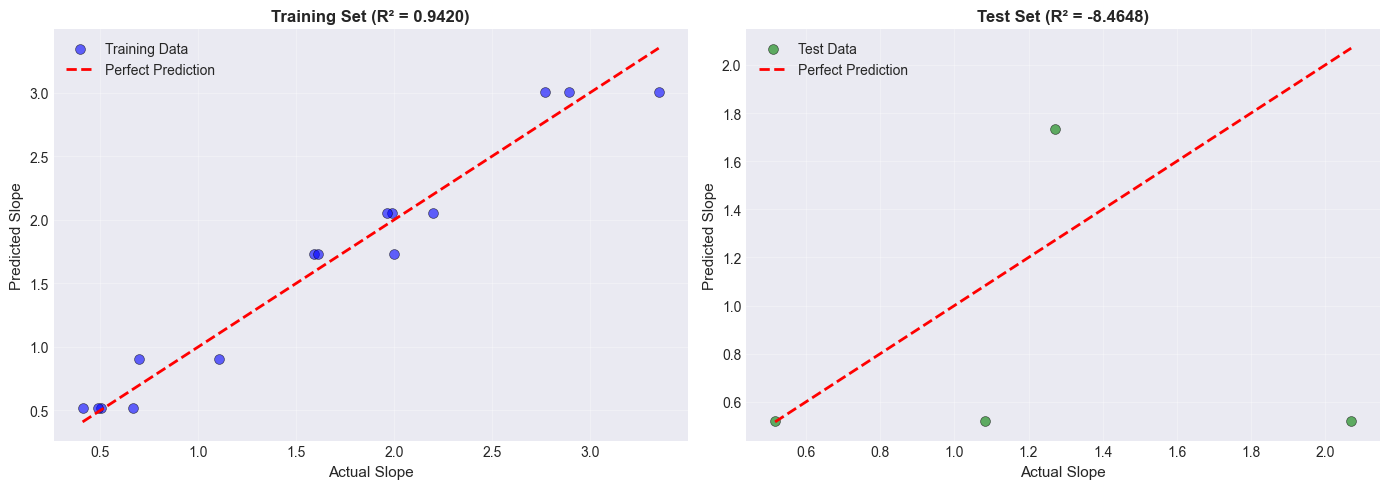

In [33]:
# Visualize: Actual vs Predicted Slopes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=50, 
               edgecolors='black', linewidth=0.5, label='Training Data')
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
            linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Slope', fontsize=11)
axes[0].set_ylabel('Predicted Slope', fontsize=11)
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Test Set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, color='green', s=50, 
               edgecolors='black', linewidth=0.5, label='Test Data')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
            linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Slope', fontsize=11)
axes[1].set_ylabel('Predicted Slope', fontsize=11)
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

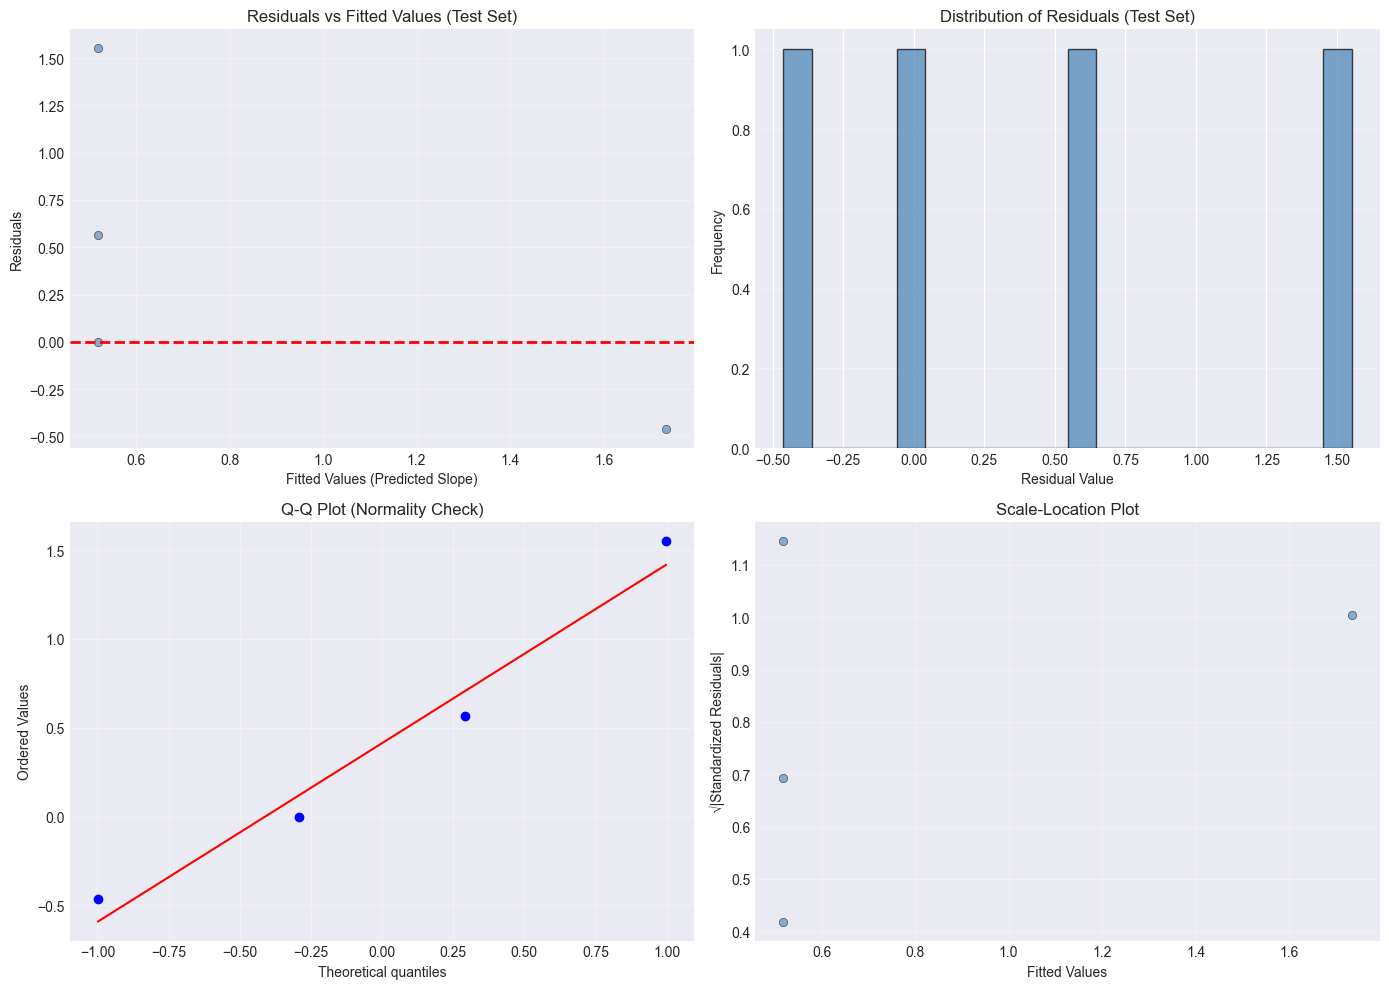

In [34]:
# Visualize: Residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(y_test_pred, y_test - y_test_pred, alpha=0.6, color='steelblue', 
                    edgecolors='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Slope)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values (Test Set)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram of Residuals
residuals_test = y_test - y_test_pred
axes[0, 1].hist(residuals_test, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals (Test Set)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Q-Q Plot
from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scale-Location Plot
std_residuals = (residuals_test - residuals_test.mean()) / residuals_test.std()
axes[1, 1].scatter(y_test_pred, np.sqrt(np.abs(std_residuals)), alpha=0.6, 
                   color='steelblue', edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Standardized Residuals|')
axes[1, 1].set_title('Scale-Location Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

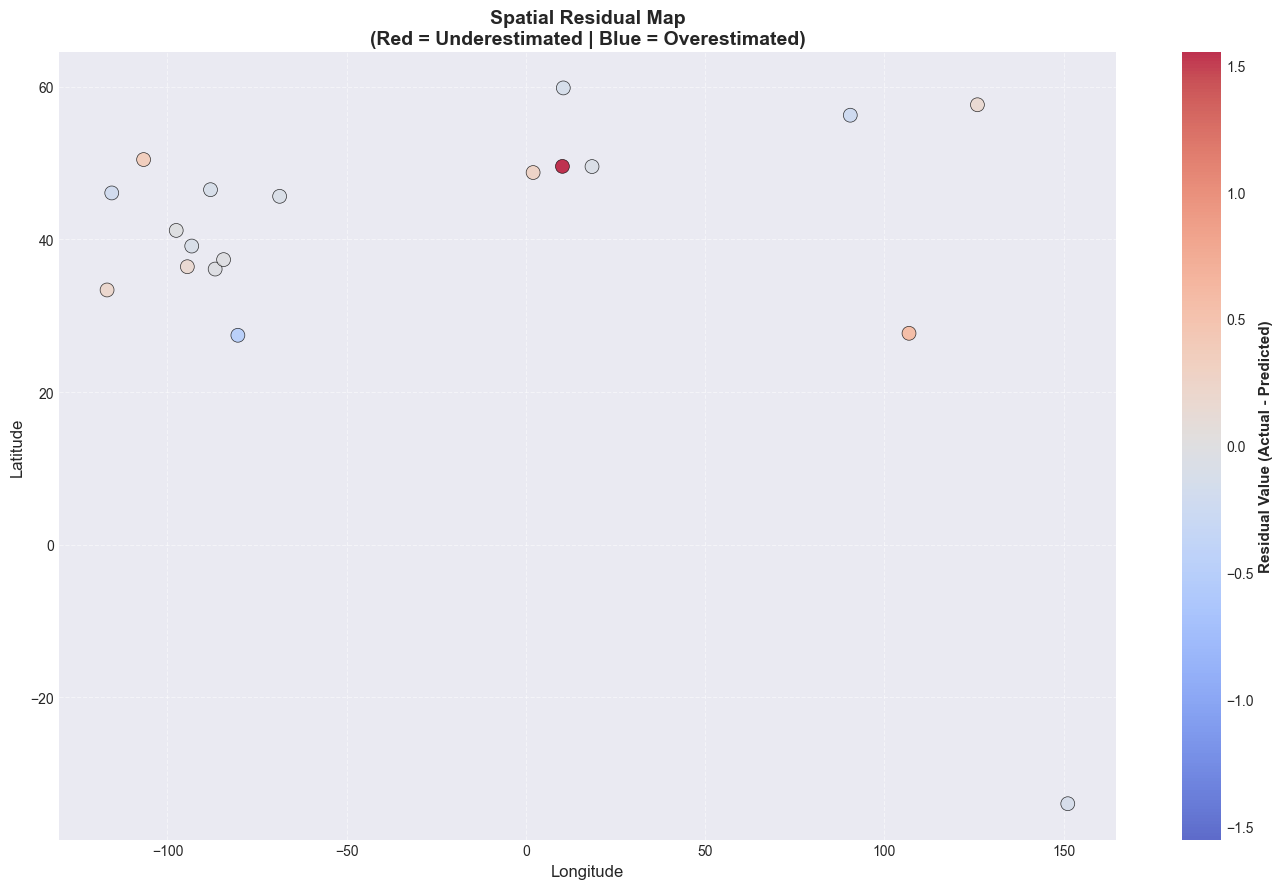

In [35]:
# Visualize: Spatial Residual Map
plt.figure(figsize=(14, 9))

# Scatter plot with residuals as colors
sc = plt.scatter(
    df_predictions['Longitude'],
    df_predictions['Latitude'],
    c=df_predictions['Residual'],
    cmap='coolwarm',
    s=100,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5,
    vmin=-np.abs(df_predictions['Residual']).max(),
    vmax=np.abs(df_predictions['Residual']).max()
)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Residual Value (Actual - Predicted)', fontsize=11, fontweight='bold')

plt.title('Spatial Residual Map\n(Red = Underestimated | Blue = Overestimated)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

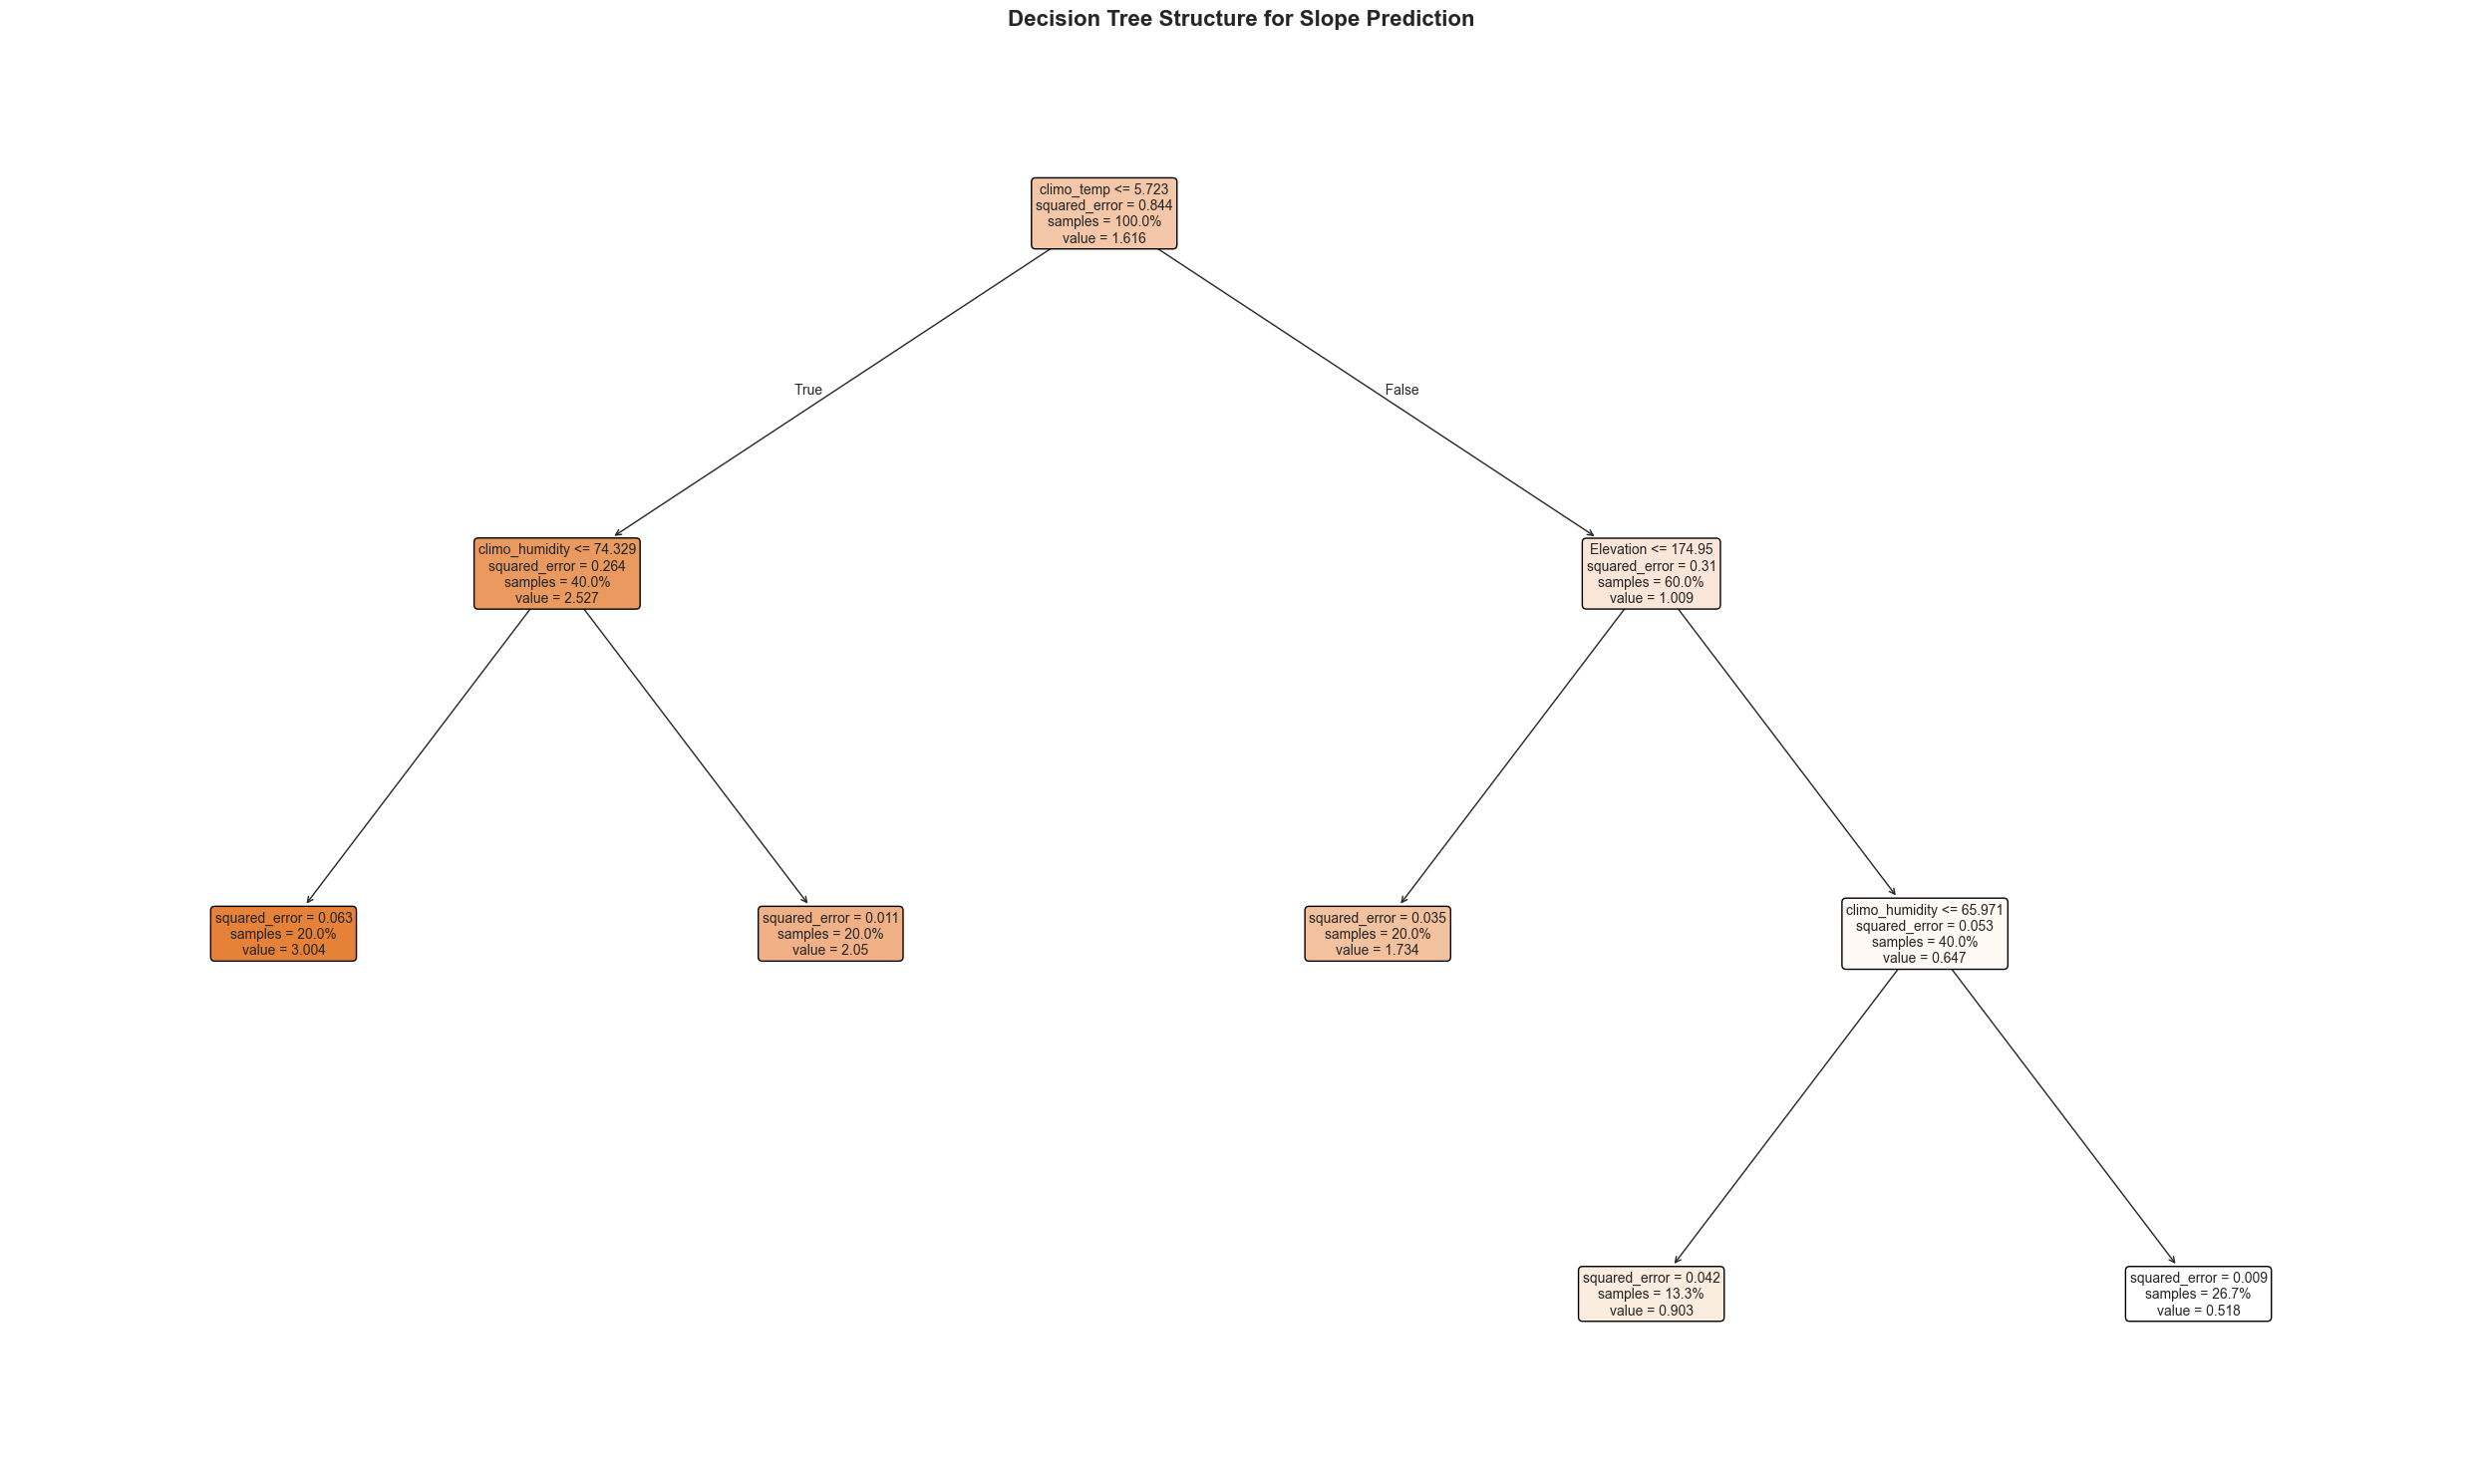

In [36]:
# Visualize: Decision Tree Structure (simplified view for readability)
plt.figure(figsize=(25, 15))
plot_tree(dt_model, feature_names=feature_cols, filled=True, fontsize=10, 
         rounded=True, proportion=True)
plt.title('Decision Tree Structure for Slope Prediction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 5: Summary and Comparison

Summary statistics and key findings:

In [37]:
# Create summary statistics
print("\n" + "="*60)
print("DECISION TREE MODEL SUMMARY")
print("="*60)

print(f"\nModel Configuration:")
print(f"  Max Depth: {dt_model.max_depth}")
print(f"  Min Samples Split: {dt_model.min_samples_split}")
print(f"  Min Samples Leaf: {dt_model.min_samples_leaf}")

print(f"\nDataset:")
print(f"  Total Stations: {len(df_clean)}")
print(f"  Training Samples: {len(X_train)}")
print(f"  Test Samples: {len(X_test)}")

print(f"\nFeatures:")
for feat, imp in zip(feature_importance['Feature'], feature_importance['Importance']):
    print(f"  {feat}: {imp:.4f}")

print(f"\nModel Performance:")
print(f"  Test R² Score: {test_r2:.4f}")
print(f"  Test RMSE: {test_rmse:.6f}")
print(f"  Test MAE: {test_mae:.6f}")

print(f"\nResidual Analysis (Full Dataset):")
print(f"  Mean Residual: {df_predictions['Residual'].mean():.6f}")
print(f"  Std Residual: {df_predictions['Residual'].std():.6f}")
print(f"  Max Underestimate: {df_predictions['Residual'].max():.6f}")
print(f"  Max Overestimate: {df_predictions['Residual'].min():.6f}")

print("\n" + "="*60)


DECISION TREE MODEL SUMMARY

Model Configuration:
  Max Depth: 10
  Min Samples Split: 5
  Min Samples Leaf: 2

Dataset:
  Total Stations: 19
  Training Samples: 15
  Test Samples: 4

Features:
  climo_temp: 0.6789
  Elevation: 0.1934
  climo_humidity: 0.1277
  Latitude: 0.0000
  Longitude: 0.0000

Model Performance:
  Test R² Score: -8.4648
  Test RMSE: 0.857331
  Test MAE: 0.645051

Residual Analysis (Full Dataset):
  Mean Residual: 0.087029
  Std Residual: 0.424387
  Max Underestimate: 1.551630
  Max Overestimate: -0.461523



In [38]:
# Save predictions to CSV
output_csv = os.path.join(OUTPUT_DIR, 'decision_tree_predictions.csv')
output_cols = ['StationID', 'StationName', 'Latitude', 'Longitude', 'Elevation',
               'climo_temp', 'climo_humidity', 'Actual_Slope', 'Predicted_Slope', 'Residual']
final_cols = [c for c in output_cols if c in df_predictions.columns]

df_predictions[final_cols].to_csv(output_csv, index=False)
print(f"\n✓ Predictions saved to: {output_csv}")


✓ Predictions saved to: ../output/decision_tree\decision_tree_predictions.csv
